# Case Study 01: Multi-Horizon Retail Demand Forecasting & Error Propagation

## Executive Summary
Large-scale retail chains face a fundamental tradeoff in item-level forecasting: complex deep learning or direct multi-model systems introduce massive operational overhead, while simple recursive single-model implementations risk severe **error accumulation** over multi-week horizons.

This case study demonstrates an end-to-end production architecture using **LightGBM** on 137 days of left-out evaluation data from the M5 (Walmart) retail dataset. We  implemented a recursive forecasting strategy—combined with anchored lag selection and a **28-day cadence for model retraining**—holds long-term error stable at **~0.847 WRMSSE**, preventing the exponential error explosion ($1.272$ WRMSSE) seen in static models.

---

## 1. Problem Framing & Core Challenges

When predicting 28-day item-level demand across thousands of volatile SKUs, production architectures must overcome three critical failure modes:

* **Feature Explosion:** Generating daily lag/rolling features across thousands of intermittent time series over multi-year horizons quickly overwhelms memory limits during training and feature pipeline updates.
* **Data Leakage:** In multi-step recursive forecasting, features for day $t+k$ depend on model predictions from day $t+k-1$. Improperly generated rolling statistics risk leaking ground-truth future target values into test predictions.
* **Error Accumulation:** Early prediction errors cascade into intermediate lag features, compounding exponentially across the 28-day forecast horizon.

---

## 2. Experimental Setup & Architecture Design

### Data & Sampling Strategy
* **Dataset:** Walmart M5 Retail Dataset: Only single store (CA_1) (high intermittent zero count at product-store level).
* **Training Lookback Window:** 2 continuous years. Rolling walk-forward validation confirmed that historical data beyond 2 years provided marginal predictive gain while significantly increasing training time and memory footprint.
* **Evaluation Horizon:** A 140-day left-out window split into 5 consecutive 28-day evaluation blocks ($W_1$ to $W_5$) to simulate real-world production deployment over nearly 5 months.

### Model Architecture: Direct vs. Recursive Choice
* **Algorithm:** LightGBM Regressor.
* **Strategy:** Recursive multi-step forecasting using a single global model. While direct forecasting (training 28 distinct models for $t+1, \dots, t+28$) avoids error feedback, managing 28 separate model artifacts in production introduces unnecessary deployment complexity and memory overhead.

---

## 3. Feature Engineering & Leakage Prevention

To keep the pipeline memory-efficient and resilient against error feedback, features were selected based on three criteria:

1. **Calendar & Contextual Features:** Calendar events, day-of-week seasonality, dynamic pricing variations, and SNAP promotion indicators.
2. **Price & Dynamic Features:** Price elasticity indicators and dynamic discount metrics to capture demand shifts caused by promotional events.
3. **Anchored Lags & Rolling Window Selection:**
   * **Excluded:** Short intermediate lags ($\text{lag}_1$ through $\text{lag}_6$). Including raw 1-day step-ahead predictions as immediate inputs caused catastrophic error feedback in preliminary tests.
   * **Included:** $\text{lag}_7$ (captures vital weekly seasonality), $\text{lag}_{28}$, $\text{lag}_{60}$, and $\text{lag}_{90}$ (anchored on fully historical, ground-truth observations).

---
## 4. Evaluation Metrics & Business Translation

Standard error metrics fail on intermittent retail time series:

* **MAPE (Mean Absolute Percentage Error):** Produces division-by-zero errors or infinite values due to frequent zero-demand days.
* **WAPE (Weighted Absolute Percentage Error):** Highly sensitive to volume scaling and unweighted demand spikes during recursive steps.

### Primary Metrics Tracked

1. **WRMSSE (Weighted Root Mean Squared Scaled Error):** The benchmark M5 metric that penalizes scale-adjusted prediction errors while correctly accounting for zero-inflated demand across hierarchy levels.
2. **Forecast Bias (Directional Error):** Tracks systematic over- or under-forecasting ($\text{Bias} = \hat{y} - y$).

$$\text{Bias} > 0 \implies \text{Overstocking Risk (Increased Holding Costs)}$$

$$\text{Bias} < 0 \implies \text{Understocking Risk (Lost Revenue \& Stockouts)}$$
---

## 5. Stress Testing Results: Static vs. Monthly Retraining

We evaluated model stability across 5 consecutive 28-day windows ($137$ days total) under two operational strategies:
1. **Static Model:** Model trained once at $W_0$ and used recursively across all 140 days.
2. **Monthly Retraining:** Model retrained on updated historical actuals at the end of each 28-day window before predicting the next window.

### Performance Summary Table

| Window Index | Date Range | WRMSSE (Static Model) | WRMSSE (Monthly Retrain) | Bias (Static Model) | Bias (Monthly Retrain) |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Window 1** | 2016-01-06 to 2016-02-03 | **0.8444** | **0.8444** | +0.1657 | +0.1657 |
| **Window 2** | 2016-02-03 to 2016-03-02 | 0.9973 | **0.8652** | +0.3317 | +0.2297 |
| **Window 3** | 2016-03-02 to 2016-03-30 | 1.1099 | **0.8419** | +0.4156 | +0.2268 |
| **Window 4** | 2016-03-30 to 2016-04-27 | 1.2028 | **0.8471** | +0.4591 | +0.2203 |
| **Window 5** | 2016-04-27 to 2016-05-22 | **1.2721** | **0.8472** | **+0.4827** | **+0.1820** |

---

## 6. Key Takeaways & Production Guidance

1. **Error Compounding is Real:** A static model degrades by **+50.6% in WRMSSE** ($0.8444 \rightarrow 1.2721$) over 140 days, with forecast bias nearly tripling (+0.4827). In practice, this leads to aggressive overstocking and locked-up working capital.
2. **Periodic Retraining Solves Concept Drift:** Retraining the LightGBM model every 28 days keeps the WRMSSE variance tightly bounded (**0.8419 to 0.8652**), closely matching our cross-validation baseline (**0.820 WRMSSE**).
3. **Operational Recommendation:** Large-scale retail forecasting engines do not require overly complex multi-model architectures. A single LightGBM recursive model coupled with anchored lag features ($\text{lag}_7, \text{lag}_{28}$) and automated monthly retraining provides optimal performance and maintainability.

In [ ]:
import sys
from pathlib import Path

# Adds the root_dir (parent of notebooks/) to sys.path
parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR/"data"/"processed"



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
# import plotly 

stress_results = pd.read_csv(BASE_DIR/'results/stress_expt_results.csv')
stress_results

,Unnamed: 0,Window,WRMSSE (Static Model),WRMSSE (Monthly Retrain),Bias (Static Model),Bias (Monthly Retrain)
0,0,W1 (Jan-Feb),0.8444,0.8444,0.1657,0.1657
1,1,W2 (Feb-Mar),0.9973,0.8652,0.3317,0.2297
2,2,W3 (Mar-Mar),1.1099,0.8419,0.4156,0.2268
3,3,W4 (Mar-Apr),1.2028,0.8471,0.4591,0.2203
4,4,W5 (Apr-May),1.2721,0.8472,0.4827,0.1820


=== Case Study 1: Multi-Window Degradation Analysis ===
 Unnamed: 0       Window  WRMSSE (Static Model)  WRMSSE (Monthly Retrain)  Bias (Static Model)  Bias (Monthly Retrain)
          0 W1 (Jan-Feb)                 0.8444                    0.8444               0.1657                  0.1657
          1 W2 (Feb-Mar)                 0.9973                    0.8652               0.3317                  0.2297
          2 W3 (Mar-Mar)                 1.1099                    0.8419               0.4156                  0.2268
          3 W4 (Mar-Apr)                 1.2028                    0.8471               0.4591                  0.2203
          4 W5 (Apr-May)                 1.2721                    0.8472               0.4827                  0.1820


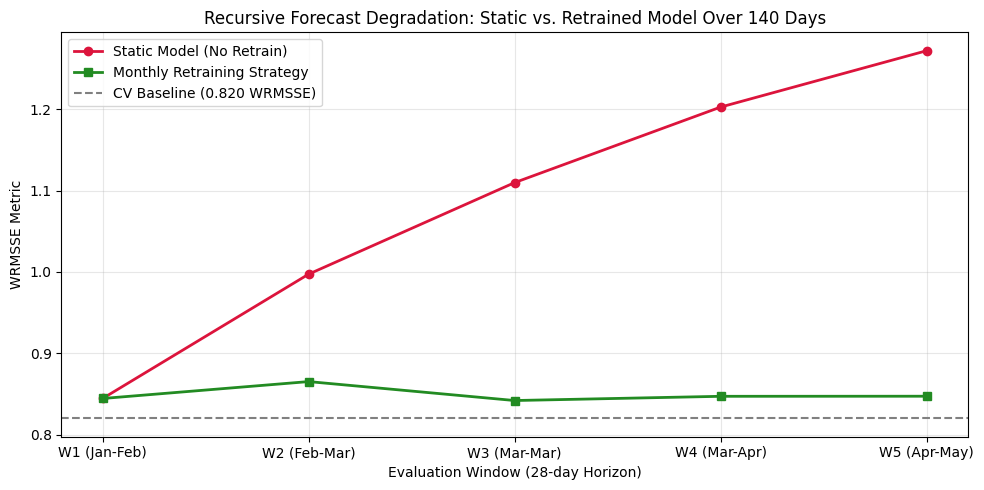

In [5]:
print("=== Case Study 1: Multi-Window Degradation Analysis ===")
print(stress_results.to_string(index=False))

# -------------------------------------------------------------------------
# 3. Visualizing Error Cascade
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    stress_results["Window"],
    stress_results["WRMSSE (Static Model)"],
    marker="o",
    linewidth=2,
    color="crimson",
    label="Static Model (No Retrain)",
)
plt.plot(
    stress_results["Window"],
    stress_results["WRMSSE (Monthly Retrain)"],
    marker="s",
    linewidth=2,
    color="forestgreen",
    label="Monthly Retraining Strategy",
)
plt.axhline(
    y=0.820,
    color="gray",
    linestyle="--",
    label="CV Baseline (0.820 WRMSSE)",
)

plt.title("Recursive Forecast Degradation: Static vs. Retrained Model Over 140 Days")
plt.xlabel("Evaluation Window (28-day Horizon)")
plt.ylabel("WRMSSE Metric")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(BASE_DIR/"case_studies/wrmsse_degradation.png")
plt.show()